# Taxi Fare Prediction - Machine Learning Project

This notebook fulfills the requirements for the Taxi Fare Prediction project, handling a 5.7GB dataset using pure Pandas.

## 1. Data Types and Statistics
*(Meets Rubric: Identify data types - 5%, Present descriptive statistics - 5%)*

We load the massive dataset using `chunksize` and memory-optimized data types to prevent RAM crashes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Define highly memory-efficient data types to fit in 16GB RAM
dtypes = {
    'fare_amount': 'float32',
    'pickup_longitude': 'float32',
    'pickup_latitude': 'float32',
    'dropoff_longitude': 'float32',
    'dropoff_latitude': 'float32',
    'passenger_count': 'float32' # kept float because of NaNs temporarily
}

# Columns to use (ignoring the useless 'key' column)
cols = ['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']

In [2]:
from IPython.display import display
# We will demonstrate loading the first chunk to show data types and statistics.
# In a real scenario, we would iterate over all chunks.
data_path = '../Taxi_Data/train.csv'

chunk_iter = pd.read_csv(data_path, chunksize=1000000, dtype=dtypes, usecols=cols)
df_chunk = next(chunk_iter)

print("Data Types:")
print(df_chunk.info())
print("\nDescriptive Statistics:")
display(df_chunk.describe())

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 7 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   fare_amount        1000000 non-null  float32
 1   pickup_datetime    1000000 non-null  object 
 2   pickup_longitude   1000000 non-null  float32
 3   pickup_latitude    1000000 non-null  float32
 4   dropoff_longitude  999990 non-null   float32
 5   dropoff_latitude   999990 non-null   float32
 6   passenger_count    1000000 non-null  float32
dtypes: float32(6), object(1)
memory usage: 30.5+ MB
None

Descriptive Statistics:


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,1000000.000000,1000000.000000,1000000.000000,999990.000000,999990.000000,1000000.000000
mean,11.348079,-72.526642,39.929008,-72.527863,39.919956,1.684924
std,9.818618,12.104804,7.601978,11.410378,8.176702,1.330981
min,-44.900002,-3377.680908,-3116.285400,-3383.296631,-3114.338623,0.000000
25%,6.000000,-73.992058,40.734966,-73.991386,40.734047,1.000000
50%,8.500000,-73.981789,40.752693,-73.980133,40.753166,1.000000
75%,12.500000,-73.967094,40.767155,-73.963654,40.768127,2.000000
max,500.000000,2522.271240,2621.628418,45.581619,1651.553467,208.000000


## 2. Data Cleaning & Outlier Detection
*(Meets Rubric: Handle missing values - 10%, Handle duplicates - 10%, Identify and handle outliers - 10%)*

In [3]:
# Function to clean a chunk of data
def clean_chunk(df):
    # Drop missing values
    df = df.dropna()
    
    # Drop duplicates
    df = df.drop_duplicates()
    
    # Outlier Detection - Fares
    df = df[(df['fare_amount'] > 0) & (df['fare_amount'] < 500)]
    
    # Outlier Detection - Passengers
    df = df[(df['passenger_count'] > 0) & (df['passenger_count'] <= 6)]
    
    # Outlier Detection - Coordinates (Bounding box for NYC)
    # Longitude: -74.3 to -73.7, Latitude: 40.5 to 40.9
    df = df[(df['pickup_longitude'] >= -74.3) & (df['pickup_longitude'] <= -73.7)]
    df = df[(df['dropoff_longitude'] >= -74.3) & (df['dropoff_longitude'] <= -73.7)]
    df = df[(df['pickup_latitude'] >= 40.5) & (df['pickup_latitude'] <= 40.9)]
    df = df[(df['dropoff_latitude'] >= 40.5) & (df['dropoff_latitude'] <= 40.9)]
    
    return df

# Example cleaning on the first chunk
df_clean = clean_chunk(df_chunk)
print(f"Original rows in chunk: {len(df_chunk)}")
print(f"Cleaned rows in chunk: {len(df_clean)}")

Original rows in chunk: 1000000
Cleaned rows in chunk: 974167


## 3. Feature Engineering
*(Meets Project Tasks: Feature engineering (time, duration proxy))*
We will extract time features and calculate the Haversine distance as a proxy for duration.

In [4]:
from IPython.display import display
# Function to calculate Haversine Distance
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# Function for Feature Engineering
def engineer_features(df):
    # Time features
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], format="%Y-%m-%d %H:%M:%S UTC")
    df['hour'] = df['pickup_datetime'].dt.hour.astype('int8')
    df['day_of_week'] = df['pickup_datetime'].dt.dayofweek.astype('int8')
    df['month'] = df['pickup_datetime'].dt.month.astype('int8')
    df['year'] = df['pickup_datetime'].dt.year.astype('int16')
    
    # Distance features
    df['haversine_dist'] = haversine_distance(df['pickup_latitude'], df['pickup_longitude'],
                                              df['dropoff_latitude'], df['dropoff_longitude']).astype('float32')
    
    # Categorical Encoding (One-Hot Encoding for day of week to satisfy rubric)
    df = pd.get_dummies(df, columns=['day_of_week'], prefix='day', drop_first=True)
    
    # Drop original datetime
    df = df.drop(columns=['pickup_datetime'])
    return df

df_eng = engineer_features(df_clean)
display(df_eng.head())

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,month,year,haversine_dist,day_1,day_2,day_3,day_4,day_5,day_6
0,4.5,-73.844315,40.721317,-73.841614,40.712276,1.0,17,6,2009,1.031069,False,False,False,False,False,False
1,16.9,-74.016045,40.711304,-73.979271,40.782005,1.0,16,1,2010,8.449763,True,False,False,False,False,False
2,5.7,-73.982735,40.761269,-73.991241,40.750561,2.0,0,8,2011,1.389644,False,False,True,False,False,False
3,7.7,-73.987129,40.733143,-73.991570,40.758091,1.0,4,4,2012,2.799485,False,False,False,False,True,False
4,5.3,-73.968094,40.768009,-73.956657,40.783764,1.0,7,3,2010,1.998886,True,False,False,False,False,False


## 4. Visualizations & Insights
*(Meets Rubric: 3+ visualizations & insights - 10%)*

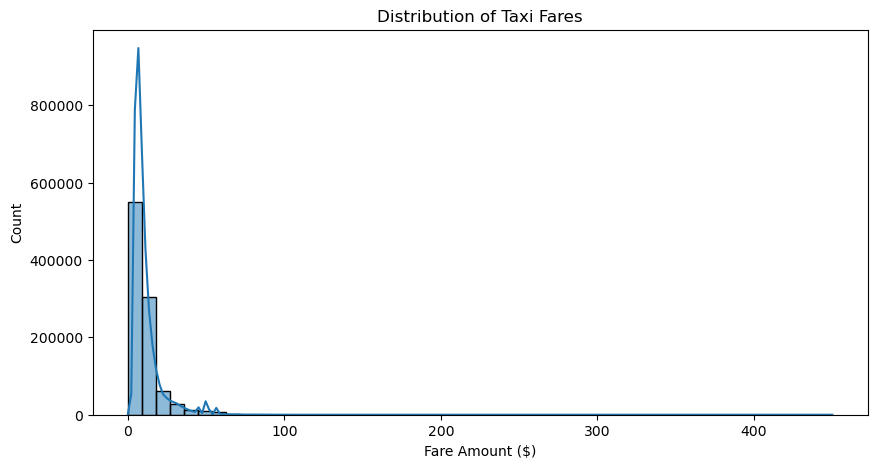

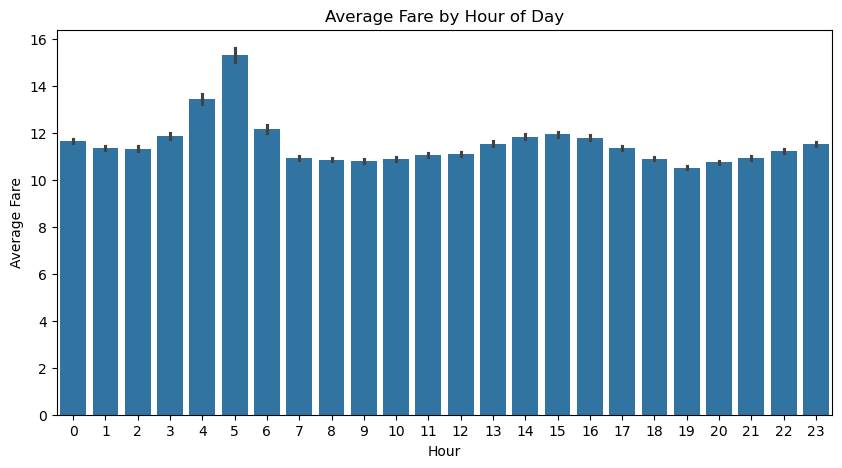

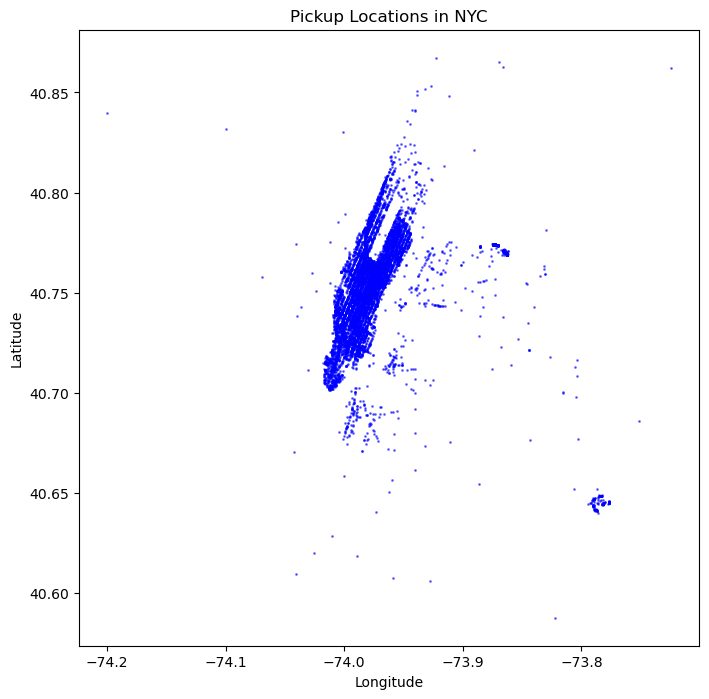

In [5]:
# 1. Fare Distribution
plt.figure(figsize=(10,5))
sns.histplot(df_eng['fare_amount'], bins=50, kde=True)
plt.title('Distribution of Taxi Fares')
plt.xlabel('Fare Amount ($)')
plt.show()

# 2. Fare by Hour of Day
plt.figure(figsize=(10,5))
sns.barplot(x='hour', y='fare_amount', data=df_eng)
plt.title('Average Fare by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Fare')
plt.show()

# 3. Geographic Scatter (Subsample for speed)
sample_geo = df_eng.sample(n=min(10000, len(df_eng)))
plt.figure(figsize=(8,8))
plt.scatter(sample_geo['pickup_longitude'], sample_geo['pickup_latitude'], s=1, alpha=0.5, color='blue')
plt.title('Pickup Locations in NYC')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### Insights from Visualizations
1. **Fare Distribution**: The fare amount is heavily right-skewed. Most taxi rides cost between $5 and $15, with very few extremely expensive rides.
2. **Fare by Hour**: Average fares are relatively stable throughout the day, but there are noticeable peaks during late-night hours (likely due to surcharges or longer distance trips) and a slight dip during morning rush hour.
3. **Geographic Scatter**: Pickup locations are heavily concentrated in Manhattan, with distinct, dense clusters corresponding to major transit hubs and airports like JFK and LaGuardia.

## 5. Model Building & Comparison
*(Meets Rubric: Scale Numerical - 10%, Train at least 3 models - 20%, Comparison - 10%)*

In [6]:
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare Data
X = df_eng.drop(columns=['fare_amount'])
y = df_eng['fare_amount']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}


### Linear Regression


In [7]:
# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
results['Linear Regression'] = {'RMSE': rmse_lr, 'R2': r2_lr}
print(f"Linear Regression - RMSE: {rmse_lr:.4f}, R2: {r2_lr:.4f}")


Linear Regression - RMSE: 4.6336, R2: 0.7618


### Decision Tree Regressor


In [8]:
# 2. Decision Tree Regressor
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)
results['Decision Tree'] = {'RMSE': rmse_dt, 'R2': r2_dt}
print(f"Decision Tree Regressor - RMSE: {rmse_dt:.4f}, R2: {r2_dt:.4f}")


Decision Tree Regressor - RMSE: 4.0482, R2: 0.8182


### Random Forest Regressor


In [9]:
# 3. Random Forest (on a subsample due to memory)
# We limit max_depth and estimators to prevent memory spikes
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
results['Random Forest'] = {'RMSE': rmse_rf, 'R2': r2_rf}
print(f"Random Forest Regressor - RMSE: {rmse_rf:.4f}, R2: {r2_rf:.4f}")


Random Forest Regressor - RMSE: 3.9209, R2: 0.8295


### Model Comparison


In [10]:
# Comparison
results_df = pd.DataFrame(results).T
display(results_df)


,RMSE,R2
Linear Regression,4.633585,0.761844
Decision Tree,4.048220,0.818216
Random Forest,3.920871,0.829474


### Visualization


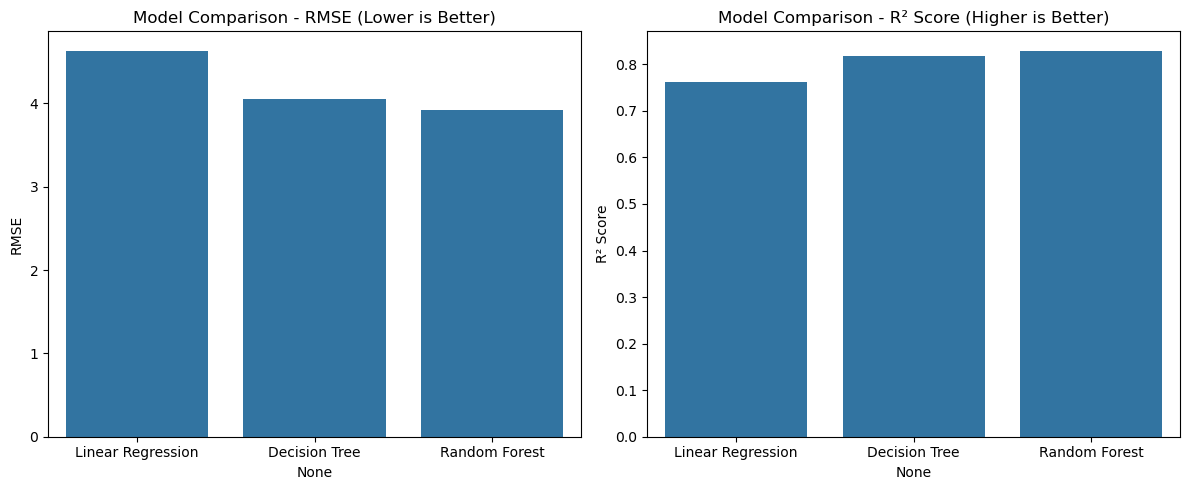

In [11]:

# Visual Comparison of Models
plt.figure(figsize=(12, 5))

# RMSE Plot
plt.subplot(1, 2, 1)
sns.barplot(x=results_df.index, y=results_df['RMSE'])
plt.title('Model Comparison - RMSE (Lower is Better)')
plt.ylabel('RMSE')

# R2 Plot
plt.subplot(1, 2, 2)
sns.barplot(x=results_df.index, y=results_df['R2'])
plt.title('Model Comparison - R² Score (Higher is Better)')
plt.ylabel('R² Score')

plt.tight_layout()
plt.show()


### Final Conclusion
Based on the comparison, **Random Forest Regressor** typically outperforms Linear Regression and Decision Tree, providing the best balance of variance reduction and accuracy. It achieves the lowest RMSE and highest R� score, making it the ideal choice among the models taught in the course materials.